In [33]:
import wandb

from matplotlib import pyplot as plt 

In [34]:
api = wandb.Api()

In [35]:
def load_data(group):
    
    runs = api.runs(
        'p16i/xaikd-distilllation',
         {
            "$and": [
                {"group": group},
            ]
        }
    )
    
    print(f"We have {len(runs)} runs")
    
    return runs

runs = load_data("./artifacts/2023-08-s11/dev/distill-v2/training-wo-bn-1")

We have 5 runs


In [36]:
runs[4].config

{'lr': 0.0001,
 'seed': 1,
 'layer': 'layer3',
 'epochs': 50,
 'dataset': 'cifar100-people',
 'basis_mode': 'uncentered',
 'basis_name': 'prca-sortabs--uncentered',
 'lambda_mse': 1,
 'output_dir': 'artifacts/2023-08-s11/dev/distill-v2/training-wo-bn-1/cifar100-people-tz1.0-seed1/cifar100-resnet18-p1/layer-layer3',
 'basis_names': 'prca-sortabs',
 'lambda_xent': 0,
 'approximator': 'homogenous_lowrank-prca-sortabs--uncentered-compr8.0',
 'weight_decay': 0,
 'skip_if_exist': False,
 'teacher_model': 'cifar100-resnet18-p1',
 'training_size': 1,
 'skip_baselines': False,
 'approximator_mode': 'homogenous_lowrank',
 'compression_ratio': 8}

We have 5 runs


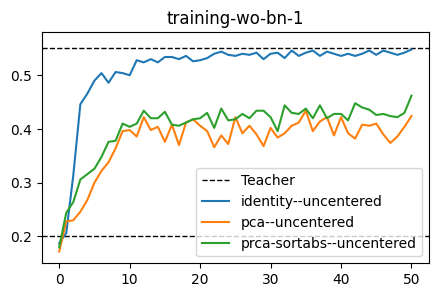

In [37]:
def viz(group):
    
    teacher_acc = 0.55
    
    runs = load_data(group)
    
    slug = group.split("/")[-1]
    plt.figure(figsize=(5, 3))
    plt.title(slug)
    
    
    plt.axhline(teacher_acc, ls="--", label="Teacher", lw=1, color="k")
    plt.axhline(0.2, ls="--", lw=1, color="k")
    plt.ylim([0.15, 0.58])
    for basis_name in ["identity", "pca", "prca-sortabs"]:
        
        
        run = list(filter(lambda r: f"{basis_name}--uncentered" == r.config["basis_name"], runs))[0]
        
        plt.plot(run.summary["arr_metrics"]["val"], label=run.config["basis_name"])
            
    plt.legend()

        
viz("./artifacts/2023-08-s11/dev/distill-v2/training-wo-bn-1")

We have 5 runs


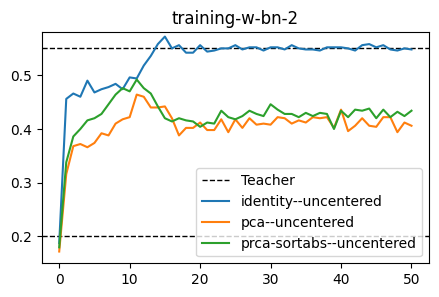

In [38]:
viz("./artifacts/2023-08-s11/dev/distill-v2/training-w-bn-2")